# Location and Room Type as Key Pricing Drivers in the NYC Airbnb Market

**Author:** Matías Lo Grasso  
**Role Target:** Junior Data Scientist / Data Analyst  

This notebook analyzes Airbnb listings in New York City to identify the main factors influencing prices and availability, with the goal of generating actionable insights for hosts.


## 1. Introduction & Business Question

Airbnb hosts operate in a highly competitive market where pricing and availability decisions directly impact revenue.
This analysis aims to answer the following question:

* Which listing characteristics most strongly influence Airbnb prices in NYC, and how can hosts use this information to optimize pricing?

The insights derived are framed from a host's decision-making perspective. 

## 2. Dataset Overview

The dataset used is **New York City Airbnb Open Data**, sourced from Kaggle.

It contains information on over 48,000 Airbnb listings, including:
- price
- neighbourhood and neighbourhood group
- room type
- availability
- number of reviews


In [94]:
# Import the libraries that we'll use

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from scipy.stats import gaussian_kde

In [95]:
# Import the data

data = pd.read_csv('../data/AB_NYC_2019.csv')
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### 2.1 Exploring the data to understand it

In [96]:
print(data.shape)
print(data.dtypes)

(48895, 16)
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


* We have almost 50k records with string, integer, and floating point columns.

In [97]:
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 3. Data Cleaning & Preparation

Before analysis, the dataset requires basic cleaning:
- Handling problematic values
- Removing invalid prices
- Selecting relevant variables

Let's analyze the integer and floating point columns:

* We see that 'id' and 'host_id' do not present apparent problems, as the minimum and maximum values seem right. The same happens with 'latitude' and 'longitude'; here we have to remember that all this data comes from NYC. 

* The 'price' column appears to have at least one wrong value, as its minimum is zero. The 'minimum_nights' column also presents at least one problem, as its maximum is 1250 nights. 

* The 'number_of_reviews' column does not present apparent problems. 

* The 'reviews_per_month column', as stated before, has more than 10k NaNs, but it may not be a problem. We probably won't erase those records, as erasing them will reduce the data volume by ~20%. Also, those NaNs probably come from a formula error. The column records are probably calculated by dividing the number of reviews by the number of months. But if the listings are new and the number of months is zero, then a NaN would appear. We would evaluate this and decide whether to replace the NaNs with zeros or not.

* The 'calculated_host_listings_count' seems to have at least one outlier with a 327 value, but we have to analyze the data to see whether this is an error.

* Finally, the 'availability_365' has lots of zero values. This would imply that a good percentage of listings would not have availability on any day of the year. This may happen in some cases, so we would take them as good.

We will now make a few figures to better understand the data. We will also eliminate some outliers.

* Here we confirm that the columns named 'reviews_per_month' and 'last_review' each have 10052 NaNs, while the other columns seem fine. The 'name' and 'host_name' columns also appear have some NaNs. 

In [98]:
print(data.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [99]:
# We check what type of records has NaNs in the 'reviews_per_month' column

check_nans_df = data[data['reviews_per_month'].isna()]
check_nans_df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,1.005200e+04,1.005200e+04,10052.000000,10052.000000,10052.000000,10052.000000,10052.0,0.0,10052.000000,10052.000000
mean,2.257484e+07,8.068437e+07,40.732099,-73.956117,192.919021,11.519797,0.0,NaN,14.793275,104.660466
std,1.135563e+07,8.712593e+07,0.052598,0.043796,358.653017,29.207928,0.0,NaN,50.363637,139.072127
min,3.647000e+03,4.632000e+03,40.499790,-74.242850,0.000000,1.000000,0.0,NaN,1.000000,0.000000
25%,1.208404e+07,1.207519e+07,40.697570,-73.984758,70.000000,1.000000,0.0,NaN,1.000000,0.000000
50%,2.337757e+07,3.979538e+07,40.728870,-73.960175,120.000000,3.000000,0.0,NaN,1.000000,6.000000
75%,3.402092e+07,1.330001e+08,40.763643,-73.939877,200.000000,14.000000,0.0,NaN,2.000000,214.250000
max,3.648724e+07,2.743213e+08,40.911690,-73.716900,10000.000000,1000.000000,0.0,NaN,327.000000,365.000000


* We can see that all these NaNs in the 'reviews_per_month' column came from a formula error and should be zero. Therefore, let's change them to that value.

In [100]:
# Change NaNs to zeros in the 'reviews_per_month' column
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)

# Check that the correction was made
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


* Next, we plot univariate histograms and boxplots in order to understand the distribution of each variable and find outliers. We won't be analyzing the 'id', 'host_id', 'latitude' or 'longitude' columns.

C:\Users\Matías\AppData\Local\Temp\ipykernel_18236\609176333.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']].hist(ax=ax)


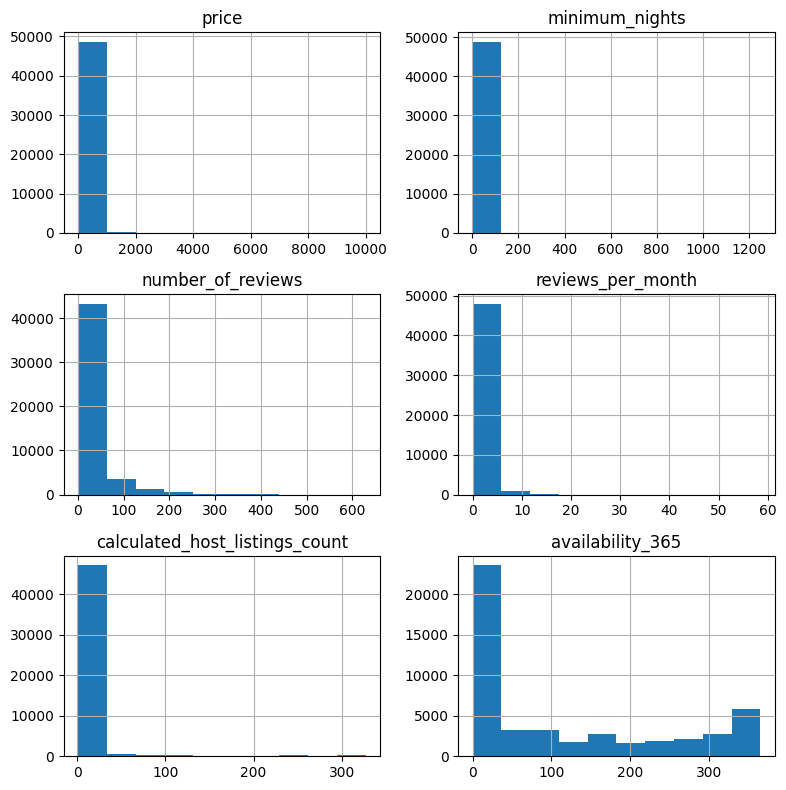

In [101]:
# Univariate Histograms

fig = plt.figure(figsize=(8,8))
ax = fig.gca()
data[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']].hist(ax=ax)
plt.tight_layout()
plt.show()   

C:\Users\Matías\AppData\Local\Temp\ipykernel_18236\3725110689.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']].plot(ax = ax,kind='box',subplots=True, layout=(4,4),sharex=False)


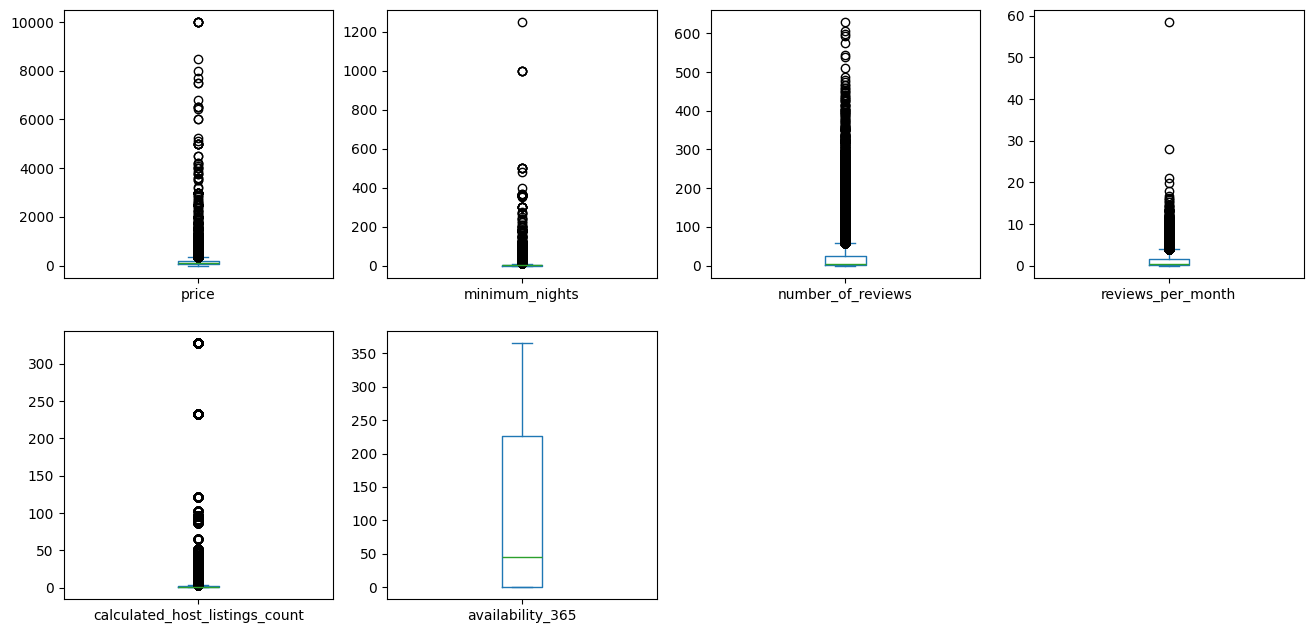

In [102]:
# Boxplots

fig = plt.figure(figsize = (16,16))
ax = fig.gca()
data[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']].plot(ax = ax,kind='box',subplots=True, layout=(4,4),sharex=False)
plt.show()  

* Let's explore ways to work with outliers

In [103]:
# Lets' define a function that removes outliers for one columns of the df

def rem_outliers(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [104]:
# First we will count the number of outliers for each column

columns_outliers = ["price","minimum_nights", "number_of_reviews","reviews_per_month","calculated_host_listings_count"]

for i in columns_outliers:
    print(f"Outliers for {i}:", len(data) - len(rem_outliers(data,i)))

Outliers for price: 2972
Outliers for minimum_nights: 6607
Outliers for number_of_reviews: 6021
Outliers for reviews_per_month: 3312
Outliers for calculated_host_listings_count: 7081


* We can see that with the IQR method, we would be eliminating a significant amount of data. Therefore, we should use another method.
* We will then winsorize at the 99th percentile the 'price' and the 'minimum_nights' columns.

In [105]:
columns_outliers = ["price","minimum_nights"]

data_filtered = data

for i in columns_outliers:
    data_filtered[i] = data[i].clip(upper=data[i].quantile(0.99))

data_filtered.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,143.956233,6.116760,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,121.935067,9.244957,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,799.000000,45.000000,629.000000,58.500000,327.000000,365.000000


* Let's do boxplots again to compare

C:\Users\Matías\AppData\Local\Temp\ipykernel_18236\346162018.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']].plot(ax = ax,kind='box',subplots=True, layout=(4,4),sharex=False)


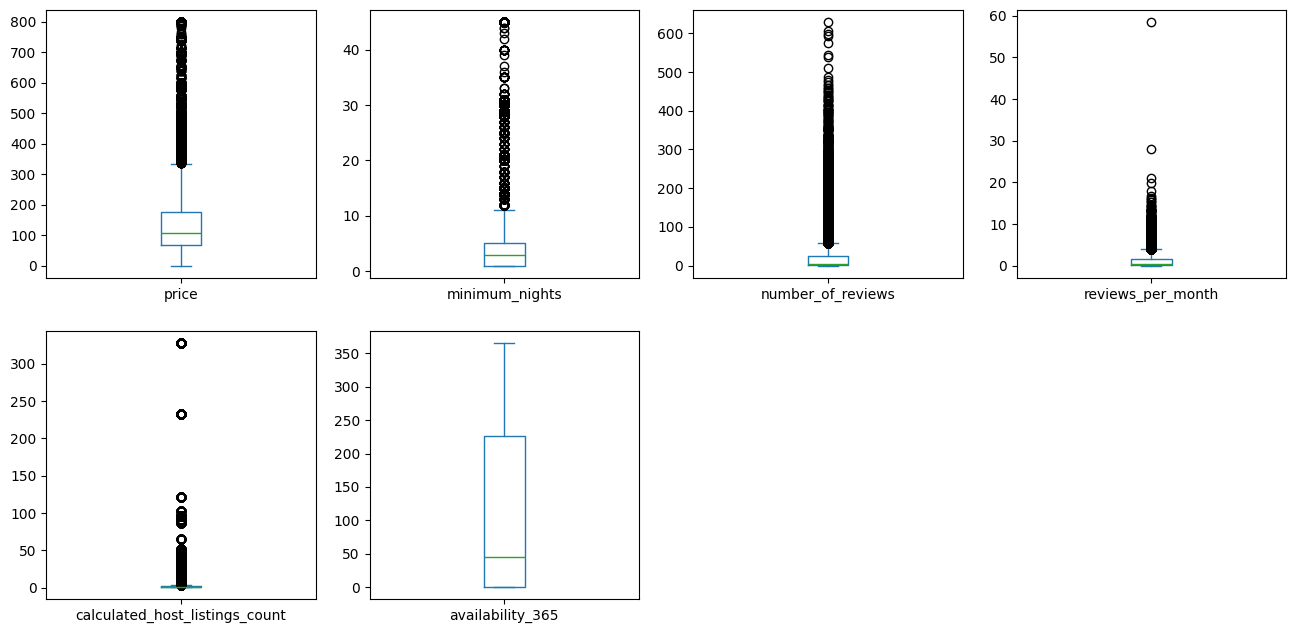

In [106]:
fig = plt.figure(figsize = (16,16))
ax = fig.gca()
data[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']].plot(ax = ax,kind='box',subplots=True, layout=(4,4),sharex=False)
plt.show()  

* We will also erase the records where the price is zero.

In [107]:
data_filtered = data_filtered[data_filtered['price'] != 0]

* Finally, let's erase irrelevant columns

In [108]:
data_filtered = data_filtered.drop(columns=['id', 'name','host_id','host_name','latitude','longitude','last_review'])

data_filtered.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0


* Let's save the new dataframe in order to use SQL and extract relevant information.

In [109]:
data_filtered.to_csv('../data/AB_NYC_2019_Clean.csv', index=False)

## 4. Exploratory Data Analysis

### 4.1 Correlation between variables

* Now that we erased the outliers, let's see the correlation between variables

In [110]:
# First, we create a new dataframe without  the string columns

data_numerical = data_filtered.select_dtypes(include=[np.number])   

# Then, we create the correlation matrix

corr_matrix = data_numerical.corr()

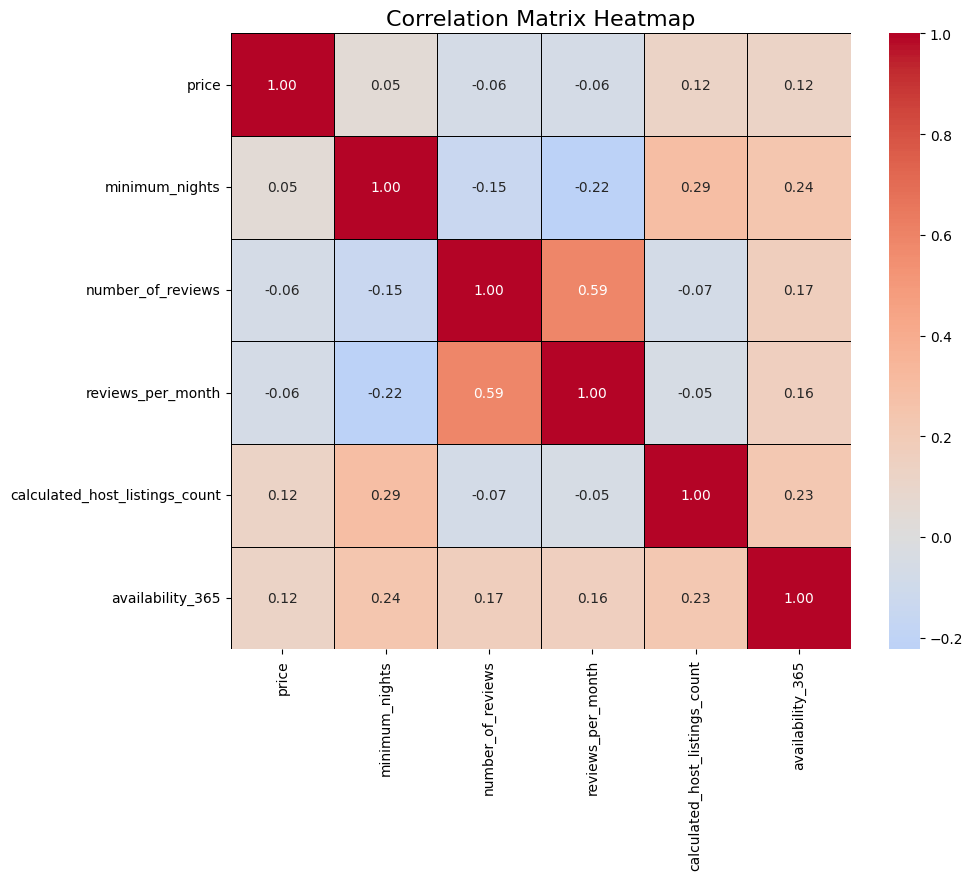

In [111]:
# Let's plot the matrix

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,           
    fmt=".2f",            
    cmap="coolwarm",      
    center=0,             
    linewidths=0.5,       
    linecolor='black'     
)
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.show()

* The correlations between variables are low. Remarkably, we can see a relatively small negative correlation between 'price' and 'longitude'. There is also a relatively small positive correlation between 'availability_365' and 'number_of_reviews', between 'availability_365' and 'calculated_host_listings_count' and between 'calculated_host_listings_count' and 'minimum_nights'.
* Low correlations suggest that pricing is driven by categorical and location-based factors rather than linear relationships between numerical variables.

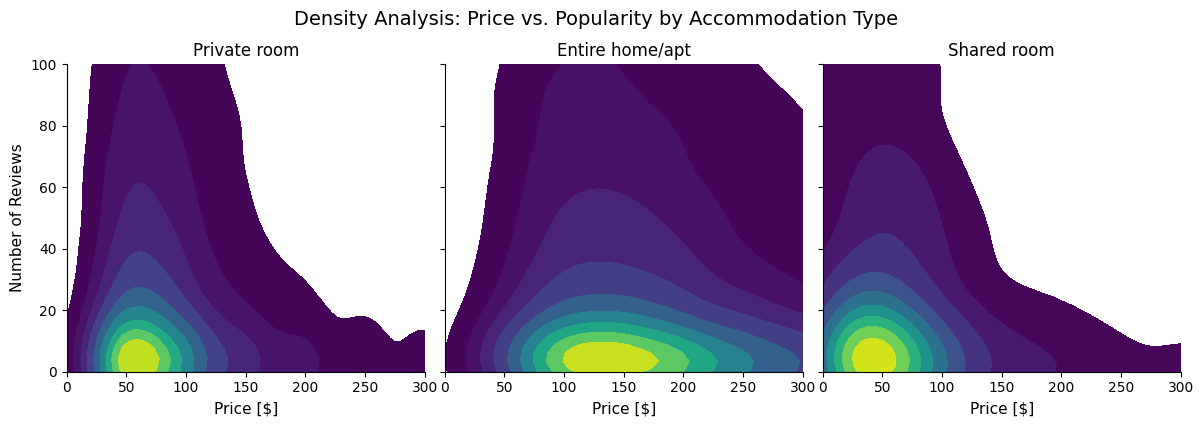

In [112]:
# Let's make different density plots for different room types
# We use the number of reviews column as a popularity gauge to evaluate the listings

g = sns.displot(
    data=data_filtered[data_filtered['room_type'].isin(['Private room', 'Entire home/apt', 'Shared room'])],
    x='price',
    y='number_of_reviews',
    col='room_type',
    kind='kde',
    fill=True,
    cmap="viridis",
    col_wrap=3,
    height=4,
    aspect=1,
    common_norm=False
)

g.set_titles(template="{col_name}", size=12)
g.set_axis_labels("Price [$]", "Number of Reviews", fontsize=11)
g.set(xlim=(0, 300), ylim=(0, 100))
plt.suptitle("Density Analysis: Price vs. Popularity by Accommodation Type", fontsize=14, y=1.05)
plt.show()

In [113]:
# Function to infer the most dense point and a range around it

def find_densest_and_high_density_region(x, y, q):
    # Create KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    # Grid
    x_grid, y_grid = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]
    grid_coords = np.vstack([x_grid.ravel(), y_grid.ravel()])
    
    # Evaluate density
    density = kde(grid_coords)
    
    # Densest point
    idx_max = np.argmax(density)
    x_max = x_grid.ravel()[idx_max]
    
    # Threshold
    threshold = np.percentile(density, q)
    
    # Price range
    high_density_mask = density > threshold
    x_high_density = x_grid.ravel()[high_density_mask]
    
    if len(x_high_density) > 0:
        x_env = (x_high_density.min(), x_high_density.max())
    else:
        x_env = (x_max, x_max)
    
    return x_max, x_env, kde

In [114]:
# Apply to different room types
for room_type in ['Private room', 'Entire home/apt', 'Shared room']:
    subset = data_filtered[data_filtered['room_type'] == room_type]
    x_max, x_env, _ = find_densest_and_high_density_region(subset['price'], subset['number_of_reviews'],q=99.9)
    x_max2, x_env2, _ = find_densest_and_high_density_region(subset['price'], subset['number_of_reviews'],q=99)
    print(f"{room_type}: Densest point = ${x_max2:.2f}, Range at 99% in price = [${x_env2[0]:.2f}, ${x_env2[1]:.2f}], Range at 99.9% in price = [${x_env[0]:.2f}, ${x_env[1]:.2f}]")      

Private room: Densest point = $57.82, Range at 99% in price = [$17.97, $153.45], Range at 99.9% in price = [$41.88, $73.76]
Entire home/apt: Densest point = $129.55, Range at 99% in price = [$65.79, $265.03], Range at 99.9% in price = [$113.61, $161.42]
Shared room: Densest point = $41.88, Range at 99% in price = [$10.00, $121.58], Range at 99.9% in price = [$33.91, $57.82]


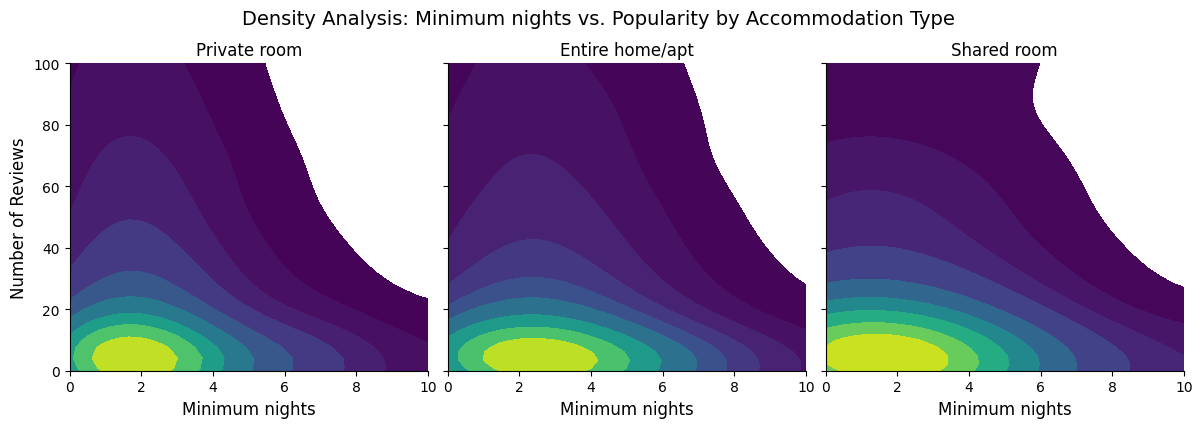

In [115]:
# Let's make different density plots for different room types
# We use the number of reviews column as a popularity gauge to evaluate the listings

g= sns.displot(
    data=data_filtered[data_filtered['room_type'].isin(['Private room', 'Entire home/apt', 'Shared room'])],
    x='minimum_nights',
    y='number_of_reviews',
    col='room_type',
    kind='kde',
    fill=True,
    cmap="viridis",
    col_wrap=3,
    height=4,
    aspect=1,
    common_norm=False
)

g.set_titles(template="{col_name}", size=12)
g.set_axis_labels("Minimum nights", "Number of Reviews", fontsize=12)
g.set(xlim=(0, 10), ylim=(0, 100))
plt.suptitle("Density Analysis: Minimum nights vs. Popularity by Accommodation Type", fontsize=14, y=1.05)
plt.show()

In [116]:
# Infer densest points

# Apply to different room types
for room_type in ['Private room', 'Entire home/apt', 'Shared room']:
    subset = data_filtered[data_filtered['room_type'] == room_type]
    x_max, x_env, _ = find_densest_and_high_density_region(subset['minimum_nights'], subset['number_of_reviews'],q=99.9)
    print(f"{room_type}: Densest point = {x_max:.2f} nights, Range at 99.9% at nights = [{x_env[0]:.2f}, {x_env[1]:.2f}]")      

Private room: Densest point = 1.89 nights, Range at 99.9% at nights = [1.00, 2.78]
Entire home/apt: Densest point = 2.33 nights, Range at 99.9% at nights = [1.44, 3.67]
Shared room: Densest point = 1.44 nights, Range at 99.9% at nights = [1.00, 2.78]


## 5. SQL-Based Analysis

SQL queries were used to replicate and validate insights obtained in Python, as well as to simulate a real-world analytics workflow.
Aggregated metrics were computed using SQL queries (see `sql/airbnb_analysis.sql`).
The results are summarized below.

In [117]:
# First, we'll import the results

queries_list = list(range(1,12))

data_dict = {}

for i in queries_list:
    data_dict[i] = pd.read_csv(f'../sql/Query{i}_results.csv')

Now, let's make useful charts.

In [118]:
# For query n°1

data_dict[1]

,neighbourhood_group,average_price,n_listings
0,Bronx,85.831193,1090
1,Brooklyn,119.422742,20095
2,Manhattan,182.961080,21660
3,Queens,96.095305,5666
4,Staten Island,101.798928,373


In [119]:
# Define colors for each neighborhood group
neighborhood_colors =['#FFA07A','#FF6B6B','#4ECDC4','#45B7D1','#98D8C8']

Text(0, 0.5, 'Percentage of listings')

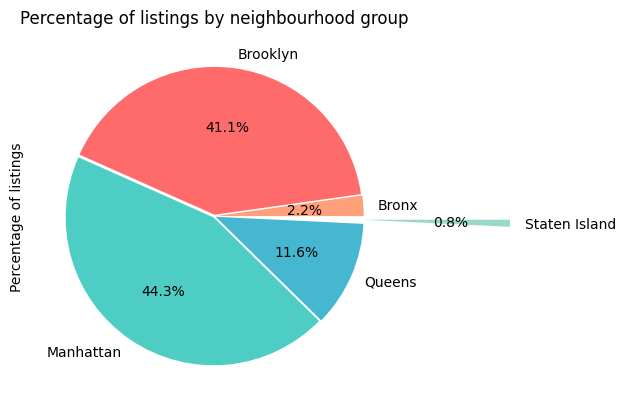

In [120]:
# Chart for query n°1

ax = data_dict[1].plot.pie(y='n_listings',labels=data_dict[1].neighbourhood_group, autopct='%1.1f%%',colors=neighborhood_colors, title='Percentage of listings by neighbourhood group',explode=[0.01,0.01,0.01,0.01,1],legend=False)
ax.set_ylabel('Percentage of listings')

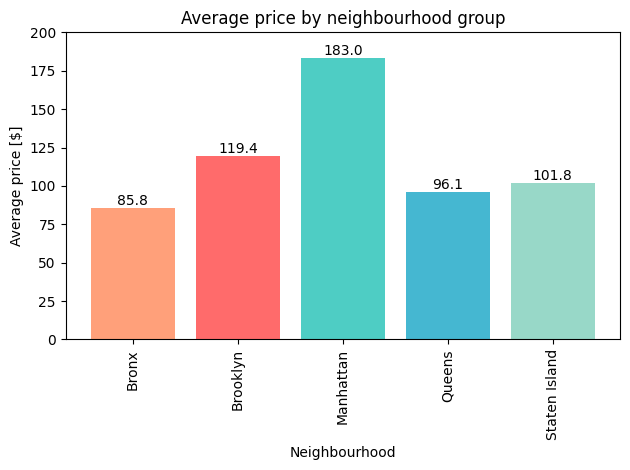

In [121]:
# Another one for query n°1

bars = plt.bar(data_dict[1].neighbourhood_group,data_dict[1].average_price,color=neighborhood_colors)

plt.xticks(rotation=90)
plt.xlabel('Neighbourhood')
plt.ylabel('Average price [$]')
plt.title('Average price by neighbourhood group')
plt.tight_layout()

# Labeling each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0,200)
plt.show()


In [122]:
data_dict[1]

,neighbourhood_group,average_price,n_listings
0,Bronx,85.831193,1090
1,Brooklyn,119.422742,20095
2,Manhattan,182.961080,21660
3,Queens,96.095305,5666
4,Staten Island,101.798928,373


In [123]:
# Evaluate how much greater is the average price in manhattan vs others neighbourhood groups

dif1 = (data_dict[1][data_dict[1]['neighbourhood_group'].str.contains('Manhattan')].average_price.item())/(data_dict[1][data_dict[1]['neighbourhood_group'].str.contains('Bronx')].average_price.item())-1
dif2 = (data_dict[1][data_dict[1]['neighbourhood_group'].str.contains('Manhattan')].average_price.item())/(data_dict[1][data_dict[1]['neighbourhood_group'].str.contains('Brooklyn')].average_price.item())-1

print(f'Manhattan has an average price {dif1*100:.0f}% higher than the Bronx')
print(f'Manhattan has an average price {dif2*100:.0f}% higher than Brooklyn')

Manhattan has an average price 113% higher than the Bronx
Manhattan has an average price 53% higher than Brooklyn


In [124]:
# For query n°2

data_dict[2]

,room_type,average_price,n_listings
0,Entire home/apt,198.342268,25407
1,Private room,86.023881,22319
2,Shared room,68.645078,1158


In [125]:
# Define colors for each room type
room_colors = ['#A0C4FF', '#BDB2FF', '#FFD6A5']

Text(0, 0.5, 'Percentage of listings')

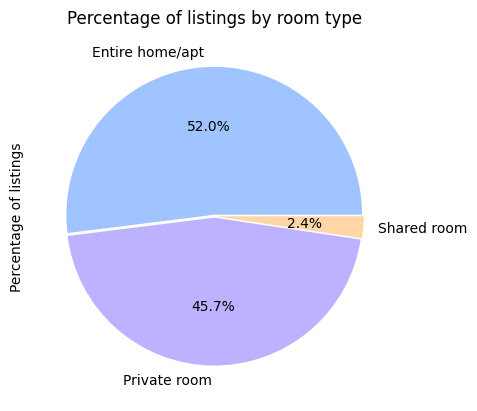

In [126]:
# Chart for query n°2

ax = data_dict[2].plot.pie(y='n_listings',labels=data_dict[2].room_type, autopct='%1.1f%%',colors=room_colors, title='Percentage of listings by room type',explode=[0.01,0.01,0.01],legend=False)
ax.set_ylabel('Percentage of listings')

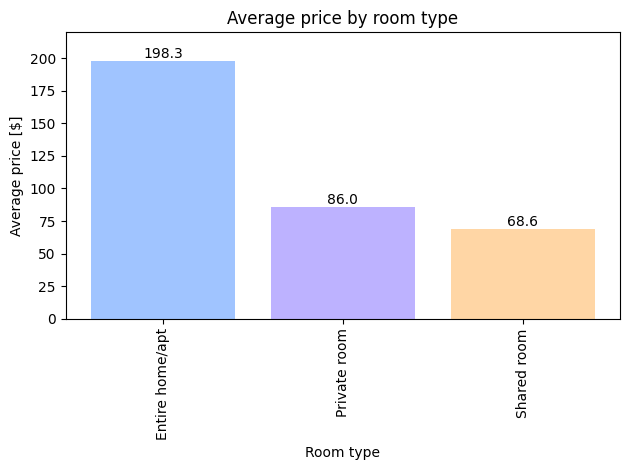

In [127]:
# Another one for query n°2

bars = plt.bar(data_dict[2].room_type,data_dict[2].average_price,color=room_colors)

plt.xticks(rotation=90)
plt.xlabel('Room type')
plt.ylabel('Average price [$]')
plt.title('Average price by room type')
plt.tight_layout()

# Labeling each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0,220)
plt.show()

In [128]:
data_dict[2]

,room_type,average_price,n_listings
0,Entire home/apt,198.342268,25407
1,Private room,86.023881,22319
2,Shared room,68.645078,1158


In [129]:
# Evaluate differences in prices per room type

dif1 = (data_dict[2][data_dict[2]['room_type'].str.contains('Entire home/apt')].average_price.item())/(data_dict[2][data_dict[2]['room_type'].str.contains('Private room')].average_price.item())-1
dif2 = (data_dict[2][data_dict[2]['room_type'].str.contains('Entire home/apt')].average_price.item())/(data_dict[2][data_dict[2]['room_type'].str.contains('Shared room')].average_price.item())-1
dif3 = (data_dict[2][data_dict[2]['room_type'].str.contains('Private room')].average_price.item())/(data_dict[2][data_dict[2]['room_type'].str.contains('Shared room')].average_price.item())-1

print(f'Entire home/apt have an average price {dif1*100:.0f}% higher than Private rooms')
print(f'Entire home/apt have an average price {dif2*100:.0f}% higher than Shared rooms')
print(f'Private rooms have an average price {dif3*100:.0f}% higher than Shared rooms')

Entire home/apt have an average price 131% higher than Private rooms
Entire home/apt have an average price 189% higher than Shared rooms
Private rooms have an average price 25% higher than Shared rooms


In [130]:
# For query n°3

data_dict[3]

,room_type,neighbourhood_group,average_price,n_listings
0,Entire home/apt,Bronx,126.976253,379
1,Entire home/apt,Brooklyn,170.579828,9558
2,Entire home/apt,Manhattan,229.879830,13198
3,Entire home/apt,Queens,143.635019,2096
4,Entire home/apt,Staten Island,146.267045,176
5,Private room,Bronx,64.278034,651
6,Private room,Brooklyn,73.921588,10126
7,Private room,Manhattan,111.059509,7982
8,Private room,Queens,68.625148,3372
9,Private room,Staten Island,62.292553,188


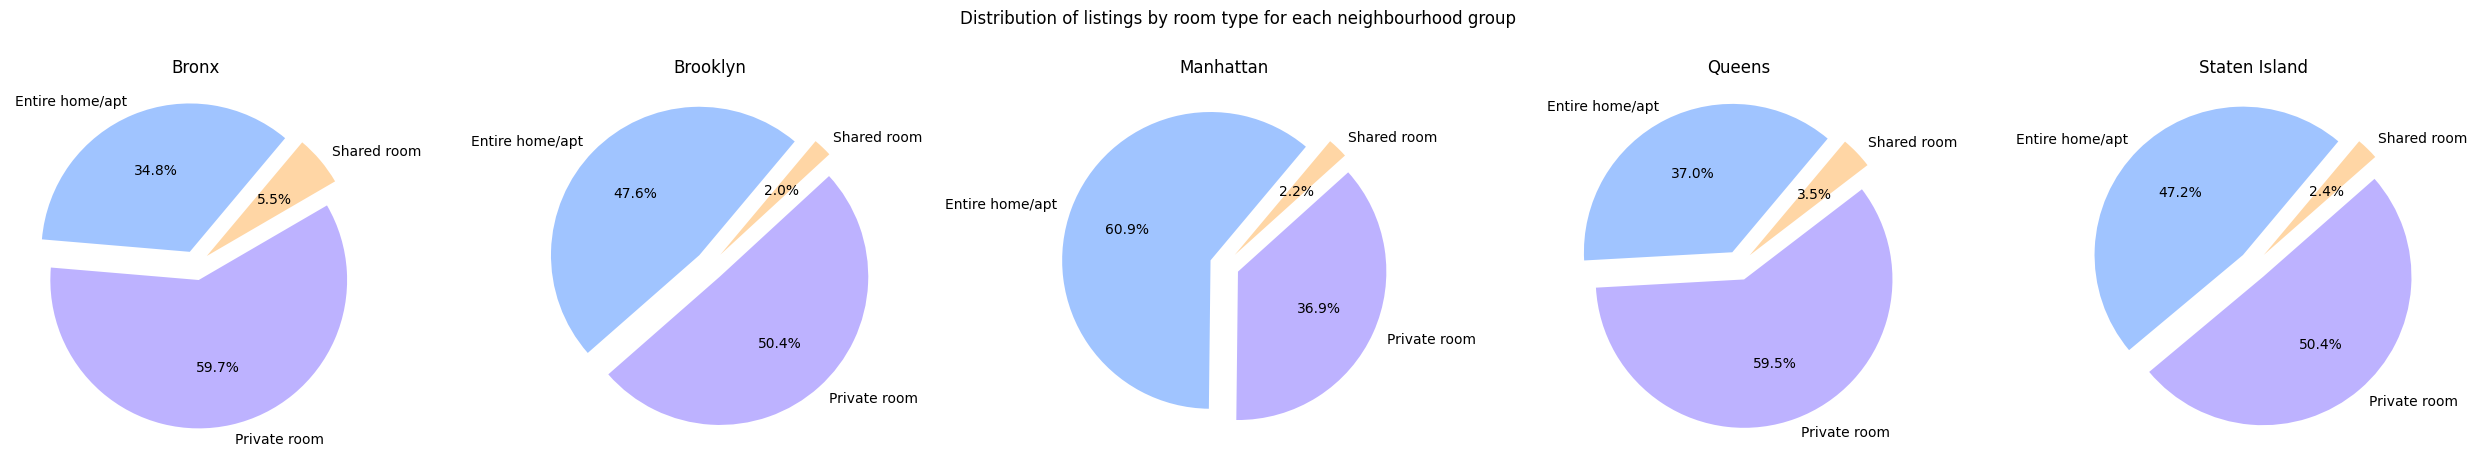

In [131]:
# Chart for query n°3


grouped = (
    data_dict[3]
    .groupby(['neighbourhood_group', 'room_type'])['n_listings']
    .sum()
    .reset_index()
)

neigh_types = grouped['neighbourhood_group'].unique()

fig, axes = plt.subplots(
    1, len(neigh_types),
    figsize=(5 * len(neigh_types), 5)
)

for ax, neigh in zip(axes, neigh_types):
    data = grouped[grouped['neighbourhood_group'] == neigh]

    ax.pie(
        data['n_listings'],
        labels=data['room_type'],
        autopct='%1.1f%%',
        startangle=50,
        explode=[0.1,0.1,0.1],
        colors=room_colors
    )

    ax.set_title(neigh)
    ax.set_ylabel('')

plt.suptitle('Distribution of listings by room type for each neighbourhood group')
plt.tight_layout()
plt.show()

In [132]:
# For query n°4

data_dict[4]

,neighbourhood_group,neighbourhood,average_price,n_listings
0,Bronx,Allerton,87.595238,42
1,Bronx,Baychester,75.428571,7
2,Bronx,Belmont,77.125000,24
3,Bronx,Bronxdale,57.105263,19
4,Bronx,Castle Hill,63.000000,9
...,...,...,...,...
216,Staten Island,Tottenville,144.857143,7
217,Staten Island,West Brighton,80.555556,18
218,Staten Island,Westerleigh,71.500000,2
219,Staten Island,Willowbrook,249.000000,1


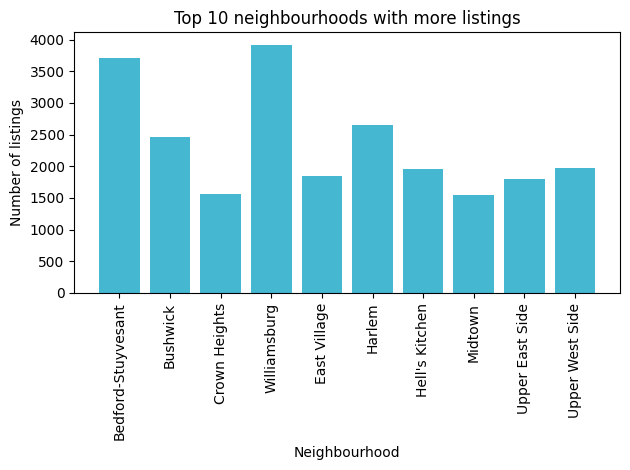

In [133]:
# Chart for query n°4

data4_modified = data_dict[4][data_dict[4].n_listings>1200]

plt.bar(data4_modified.neighbourhood, data4_modified.n_listings,color='#45B7D1')
plt.xticks(rotation=90)
plt.xlabel('Neighbourhood')
plt.ylabel('Number of listings')
plt.title('Top 10 neighbourhoods with more listings')
plt.tight_layout()
plt.show()

In [134]:
# For query n°5

data_dict[5].head()

,minimum_nights,n_listings
0,1,12717
1,2,11693
2,3,7998
3,4,3302
4,5,3033


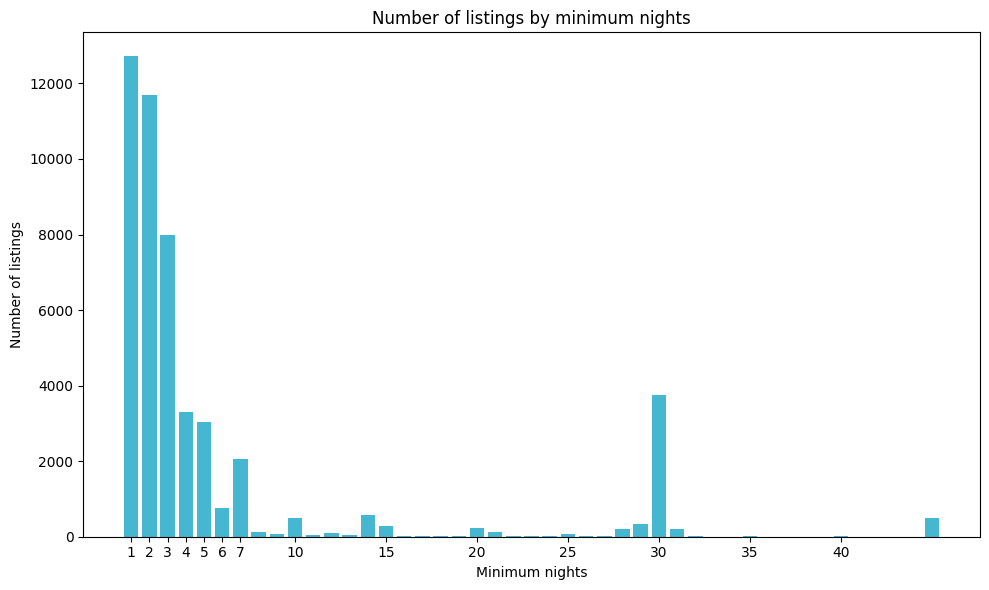

In [135]:
# Chart for query n°5

plt.figure(figsize=(10, 6))
plt.bar(data_dict[5].minimum_nights,data_dict[5].n_listings,color='#45B7D1')
plt.xlabel('Minimum nights')
plt.ylabel('Number of listings')
plt.title('Number of listings by minimum nights')
plt.tight_layout() 
plt.xticks([1,2,3,4,5,6,7,10,15,20,25,30,35,40])
plt.show()

In [136]:
for i in list(range(0,7)):
    dif = data_dict[5].n_listings[i].item()/sum(data_dict[5].n_listings)
    j=i+1
    print(f'Percentage of listings with {j} minimum nights: {dif*100:.0f}%')

dif = data_dict[5].n_listings[29].item()/sum(data_dict[5].n_listings)
print(f'Percentage of listings with 30 minimum nights: {dif*100:.0f}%')

Percentage of listings with 1 minimum nights: 26%
Percentage of listings with 2 minimum nights: 24%
Percentage of listings with 3 minimum nights: 16%
Percentage of listings with 4 minimum nights: 7%
Percentage of listings with 5 minimum nights: 6%
Percentage of listings with 6 minimum nights: 2%
Percentage of listings with 7 minimum nights: 4%
Percentage of listings with 30 minimum nights: 8%


In [137]:
# For query n°6

data_dict[6].head()

,price,n_listings
0,10,17
1,11,3
2,12,4
3,13,1
4,15,6


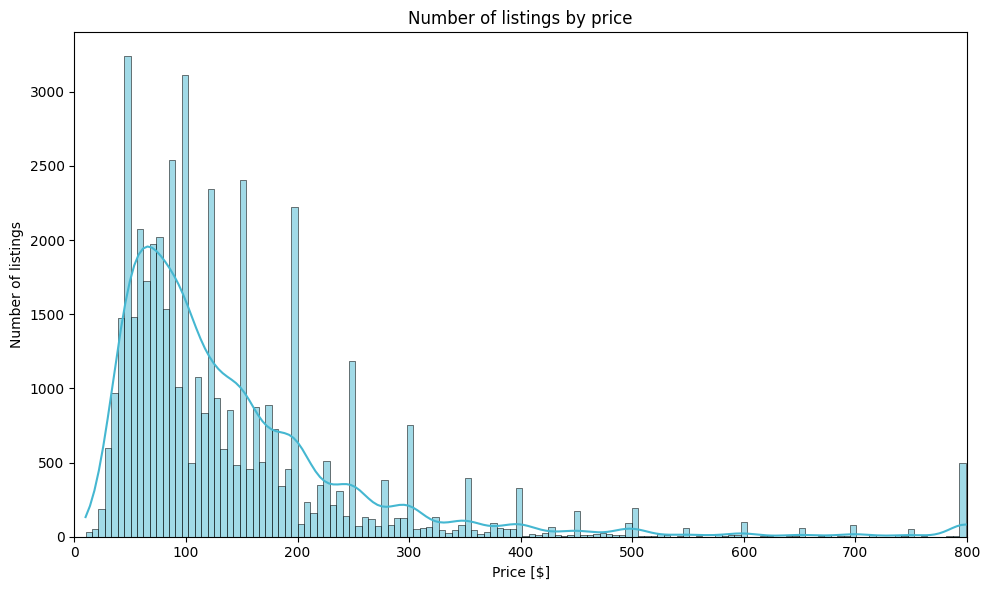

In [138]:
# Chart for query n°6

plt.figure(figsize=(10, 6))

# I ended up not using the data from the query to make the chart as I'd save time using the original dataframe

sns.histplot(data=data_filtered,x='price',kde=True,stat='count',bins='auto',color='#45B7D1')

plt.xlim(0,800)
plt.xlabel('Price [$]')
plt.ylabel('Number of listings')
plt.title('Number of listings by price')
plt.tight_layout()
plt.show()

In [139]:
# For query n°7

data_dict[7]

,neighbourhood_group,average_price,average_monthly_n_reviews,average_minimum_nights
0,Bronx,85.831193,1.474661,3.723853
1,Brooklyn,119.422742,1.049523,5.322518
2,Manhattan,182.961080,0.976827,7.379640
3,Queens,96.095305,1.567076,4.704906
4,Staten Island,101.798928,1.576381,3.973190


In [140]:
# Let's estimate the average monthly revenue by multiplicating the average price, the average monthly reviews and the average minimum nights. 
# We also assume that 75% of the guests evaluate the host. Therefore, a factor is aggregated in order to count the guests that do not leave a review.

data_dict[7]['estimated_average_monthly_revenue'] = data_dict[7]['average_price']*data_dict[7]['average_monthly_n_reviews']*data_dict[7]['average_minimum_nights']*(4/3)

# If we also know the average value of an apartment in each neighbourhood, we could also calculate the ROI per apartment in each neighbourhood.

data_dict[7]

,neighbourhood_group,average_price,average_monthly_n_reviews,average_minimum_nights,estimated_average_monthly_revenue
0,Bronx,85.831193,1.474661,3.723853,628.446772
1,Brooklyn,119.422742,1.049523,5.322518,889.477542
2,Manhattan,182.961080,0.976827,7.379640,1758.532605
3,Queens,96.095305,1.567076,4.704906,944.673717
4,Staten Island,101.798928,1.576381,3.973190,850.124279


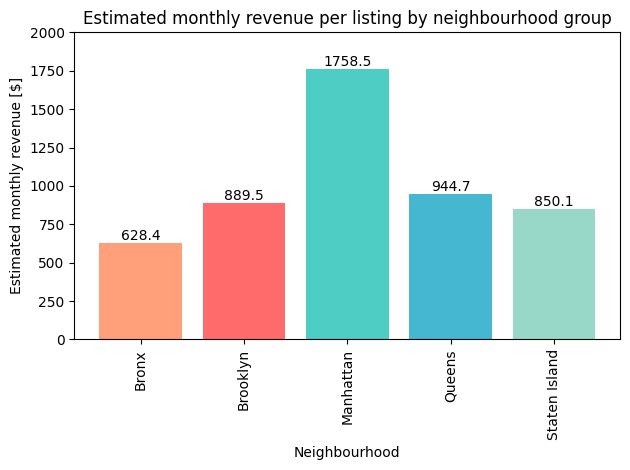

In [141]:
# Chart for query n°7

bars = plt.bar(data_dict[7].neighbourhood_group, data_dict[7].estimated_average_monthly_revenue,color=neighborhood_colors)

plt.xticks(rotation=90)
plt.xlabel('Neighbourhood')
plt.ylabel('Estimated monthly revenue [$]')
plt.title('Estimated monthly revenue per listing by neighbourhood group')
plt.tight_layout()

# Labeling for each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0,2000)
plt.show()

In [142]:
# Evaluate differences in estimated monthly average revenue per neighbourhood group

dif1 = (data_dict[7][data_dict[7]['neighbourhood_group'].str.contains('Manhattan')].estimated_average_monthly_revenue.item())/(data_dict[7][data_dict[7]['neighbourhood_group'].str.contains('Bronx')].estimated_average_monthly_revenue.item())-1
dif2 = (data_dict[7][data_dict[7]['neighbourhood_group'].str.contains('Manhattan')].estimated_average_monthly_revenue.item())/(data_dict[7][data_dict[7]['neighbourhood_group'].str.contains('Queens')].estimated_average_monthly_revenue.item())-1

print(f'Manhattan has an average estimated monthly revenue {dif1*100:.0f}% higher than the Bronx')
print(f'Manhattan has an average estimated monthly revenue {dif2*100:.0f}% higher than Queens')

Manhattan has an average estimated monthly revenue 180% higher than the Bronx
Manhattan has an average estimated monthly revenue 86% higher than Queens


In [143]:
# For query n°8

data_dict[8]

,neighbourhood_group,room_type,average_price,average_n_reviews_per_month,average_minimum_nights
0,Bronx,Entire home/apt,126.976253,1.824749,4.627968
1,Bronx,Private room,64.278034,1.317465,3.299539
2,Bronx,Shared room,59.783333,0.968833,2.616667
3,Brooklyn,Entire home/apt,170.579828,1.125443,5.652856
4,Brooklyn,Private room,73.921588,0.989826,4.921884
5,Brooklyn,Shared room,50.773723,0.754769,7.510949
6,Manhattan,Entire home/apt,229.879830,0.862133,9.131080
7,Manhattan,Private room,111.059509,1.145254,4.685793
8,Manhattan,Shared room,88.554167,1.329646,4.018750
9,Queens,Entire home/apt,143.635019,1.635038,4.573950


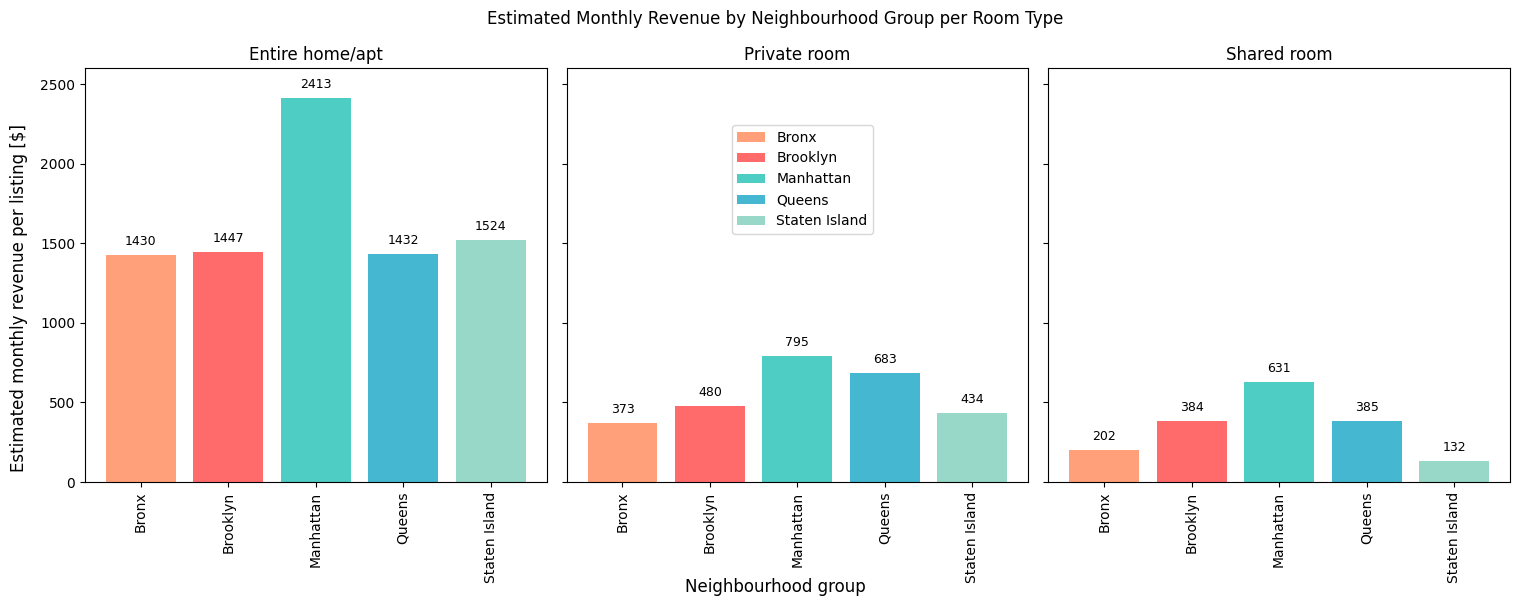

In [144]:
data_dict[8]['estimated_average_monthly_revenue'] = data_dict[8]['average_price']*data_dict[8]['average_n_reviews_per_month']*data_dict[8]['average_minimum_nights']*(4/3)

neighborhood_colors = {
    'Bronx': '#FFA07A',
    'Brooklyn': '#FF6B6B',
    'Manhattan': '#4ECDC4',
    'Queens': '#45B7D1',
    'Staten Island': '#98D8C8'
}


# Get unique room types
room_types = data_dict[8]['room_type'].unique()
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for i, room_type in enumerate(room_types):
    subset = data_dict[8][data_dict[8]['room_type'] == room_type]
    
    # Assign color to each bar
    colors = [neighborhood_colors[ng] for ng in subset['neighbourhood_group']]
    
    bars = axes[i].bar(subset['neighbourhood_group'], subset['estimated_average_monthly_revenue'], color=colors)
    
    # Annotate each bar with its value
    for bar in bars:
        height = bar.get_height()
        axes[i].annotate(f'{height:.0f}', 
                        xy=(bar.get_x() + bar.get_width() / 2, height), 
                        xytext=(0, 5), textcoords='offset points',
                        ha='center', va='bottom', fontsize=9, color='black')

    axes[i].set_title(f'{room_type}')
    axes[i].tick_params(axis='x', rotation=90)

# Common labels
plt.suptitle('Estimated Monthly Revenue by Neighbourhood Group per Room Type')
fig.text(0.5, 0.01, 'Neighbourhood group', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Estimated monthly revenue per listing [$]', va='center', rotation='vertical', fontsize=12)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=label) for label, color in neighborhood_colors.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.57, 0.8))

plt.tight_layout()
plt.ylim(0,2600)
plt.show()   

In [145]:
# Define colors for each neighborhood group
neighborhood_colors =['#FFA07A','#FF6B6B','#4ECDC4','#45B7D1','#98D8C8']

In [146]:
# For query n°9

data_dict[9]

,neighbourhood_group,average_availability
0,Bronx,165.794495
1,Brooklyn,100.217318
2,Manhattan,111.984580
3,Queens,144.451818
4,Staten Island,199.678284


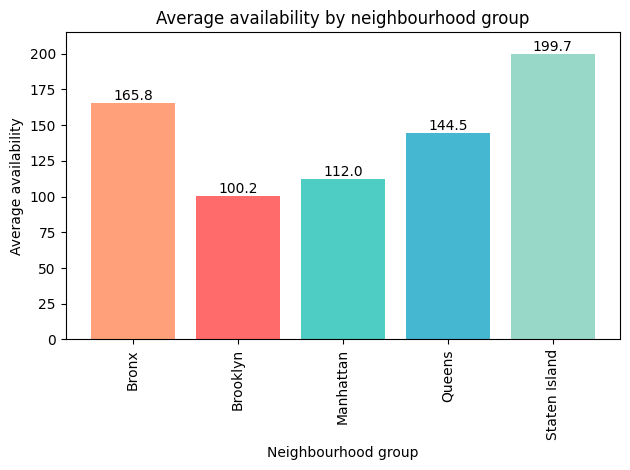

In [147]:
# Chart for query n°9

bars = plt.bar(data_dict[9].neighbourhood_group, data_dict[9].average_availability,color=neighborhood_colors)

plt.xticks(rotation=90)
plt.xlabel('Neighbourhood group')
plt.ylabel('Average availability')
plt.title('Average availability by neighbourhood group')
plt.tight_layout()

# Labeling each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0,215)
plt.show()

In [148]:
# Evaluate differences for availability per neighbourhood group

dif1 = (data_dict[9][data_dict[9]['neighbourhood_group'].str.contains('Staten Island')].average_availability.item())/(data_dict[9][data_dict[9]['neighbourhood_group'].str.contains('Brooklyn')].average_availability.item())-1
dif2 = (data_dict[9][data_dict[9]['neighbourhood_group'].str.contains('Staten Island')].average_availability.item())/(data_dict[9][data_dict[9]['neighbourhood_group'].str.contains('Bronx')].average_availability.item())-1

print(f'Staten Island has an average availability {dif1*100:.0f}% higher than  Brooklyn')
print(f'Staten Island has an average availability {dif2*100:.0f}% higher than the Bronx')

Staten Island has an average availability 99% higher than  Brooklyn
Staten Island has an average availability 20% higher than the Bronx


In [149]:
# For query n°10

data_dict[10]



,neighbourhood_group,neighbourhood,n_listings,average_availability
0,Brooklyn,Downtown Brooklyn,83,39.481928
1,Manhattan,Morningside Heights,346,43.054913
2,Brooklyn,Navy Yard,14,48.928571
3,Brooklyn,Cobble Hill,99,63.212121
4,Manhattan,Stuyvesant Town,37,65.108108
5,Brooklyn,Brooklyn Heights,154,66.038961
6,Manhattan,Civic Center,52,68.269231
7,Brooklyn,Columbia St,42,69.095238
8,Manhattan,Nolita,253,69.810277
9,Brooklyn,Carroll Gardens,233,71.669528


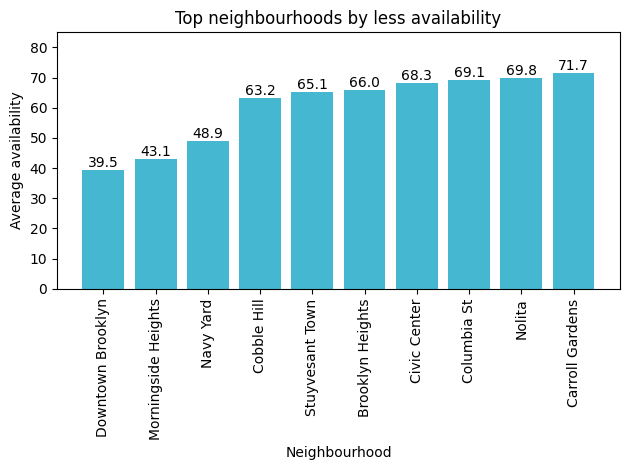

In [150]:
# Chart for query n°10

bars = plt.bar(data_dict[10].neighbourhood[0:10], data_dict[10]['average_availability'][0:10],color='#45B7D1')

plt.xticks(rotation=90)
plt.xlabel('Neighbourhood')
plt.ylabel('Average availability')
plt.title('Top neighbourhoods by less availability')
plt.tight_layout()

# Labeling each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0,85)
plt.show()

In [151]:
print('Top 5 neighbourhoods in Manhattan with less availability')
print(data_dict[10][data_dict[10].neighbourhood_group=='Manhattan'].neighbourhood[0:5])

Top 5 neighbourhoods in Manhattan with less availability
1     Morningside Heights
4         Stuyvesant Town
6            Civic Center
8                  Nolita
10       Roosevelt Island
Name: neighbourhood, dtype: object


In [152]:
# For query n°11

data_dict[11]

,neighbourhood_group,total_reviews_per_month
0,Bronx,1607.0
1,Brooklyn,21090.0
2,Manhattan,21158.0
3,Queens,8879.0
4,Staten Island,588.0


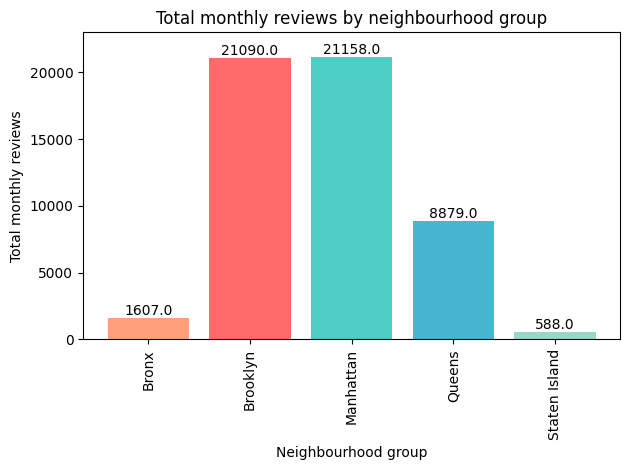

In [153]:
# Chart for query n°12

bars = plt.bar(data_dict[11].neighbourhood_group, data_dict[11].total_reviews_per_month,color=neighborhood_colors)

plt.xticks(rotation=90)
plt.xlabel('Neighbourhood group')
plt.ylabel('Total monthly reviews')
plt.title('Total monthly reviews by neighbourhood group')
plt.tight_layout()

# # Labeling each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0,23000)
plt.show()

## Key Insights

- **Listings are highly concentrated in Manhattan and Brooklyn**, which together account for over 85% of all listings. Manhattan represents 44.3% of the total supply, followed closely by Brooklyn with 41.1%, while Queens (11.6%), the Bronx (2.2%), and Staten Island (0.8%) play a much smaller role.

- **Manhattan has the highest average nightly price**, at approximately $183 per night. Prices in Manhattan are between 53% and 113% higher than in the other boroughs, reflecting higher demand.

- **Entire home/apartment listings dominate the market**, representing 52% of all listings, followed by private rooms (45.7%) and shared rooms (2.4%).

- **Room type is a major driver of price differences**. Entire homes/apartments are priced, on average, 131% higher than private rooms, while private rooms are approximately 25% more expensive than shared rooms.

- Based on typical price ranges, **guests usually pay between** $114 and $161 per night for an entire home/apartment, between $42 and $74 for private rooms, and between $34 and $58 for shared rooms.

- **Minimum night requirements are generally low**, with 26% of listings requiring only one night and 66% requiring three nights or fewer. Only 8% of listings require a minimum stay of 30 nights, suggesting that **short-term stays dominate the market**.

- **Manhattan also shows the highest estimated average monthly revenue**, at approximately $1,759. This figure is between 86% and 180% higher than in other boroughs, reinforcing its strong revenue potential despite higher competition.

- **Staten Island exhibits the highest average availability**, between 20% and 99% higher than other boroughs, **indicating lower occupancy**. In contrast, **Brooklyn and Manhattan show the lowest availability, suggesting stronger and more consistent demand**.

Observations:
- All prices correspond to one-night stays, as listed in the dataset.
- The estimated monthly revenue is a simplified approximation, calculated using nightly price and minimum night requirements, among others. Actual revenue is likely higher, as this approach does not account for occupancy rates, seasonality, or longer stays beyond the minimum requirement.

## Conclusions & Recommendations

This analysis shows that pricing dynamics in NYC Airbnb listings are primarily driven by location and room type, with Manhattan and entire home/apartment listings consistently commanding higher prices and revenues.

### Recommendations for hosts and investors:

- **Prioritize entire home/apartment listings when possible**, as they generate significantly higher nightly prices and estimated monthly revenue.
- **Maintain low minimum night requirements, ideally one night**, to maximize booking flexibility and potential occupancy.
- **Manhattan appears to be the most attractive borough for investment**, given its low availability and highest estimated average monthly revenue. **Brooklyn represents a strong secondary option**, offering high demand at comparatively lower price levels.
- Within Manhattan, neighborhoods such as Morningside Heights, Stuyvesant Town, Civic Center, Nolita, and Roosevelt Island stand out due to their relatively lower availability, suggesting stronger demand and potential revenue opportunities.

Further analysis could integrate real estate acquisition costs to estimate return on investment (ROI) and better determine which neighborhoods and listing types offer the most favorable risk–reward profiles. Additionally, review sentiment analysis could be used to identify service and amenity improvements that may positively impact pricing and occupancy.

## Limitations
- The dataset represents a historical snapshot from the 2010s and does not reflect more recent market dynamics.
- Due to the absence of time-indexed observations, no temporal or seasonality analysis could be performed.
- Estimated monthly revenue should not be interpreted as actual income.

## Next Steps
- Conduct time-series analysis to study pricing and demand trends over time.
- Develop predictive models for price estimation and optimization, including traditional machine learning approaches and, if appropriate, more advanced deep learning techniques.